# 02 — Temporal Mapping income_w1–income_w4

**Fingo Income Predictor** | Tim CC26-PSU217

Input:
- `data/processed/survey_clean.csv`

Output:
- `data/processed/survey_temporal_mapped.csv`
- `data/processed/survey_weekly_income_long.csv`

Definisi:
- `income_w1` = H-7 s/d H-1 dari timestamp responden (terbaru)
- `income_w2` = H-14 s/d H-8
- `income_w3` = H-21 s/d H-15
- `income_w4` = H-28 s/d H-22 (terlama)

Urutan kronologis model: `income_w4 → income_w3 → income_w2 → income_w1`

In [1]:
# GIT PULL — Sinkronisasi terbaru dari remote sebelum mulai
import os, shutil, subprocess

try:
    from google.colab import userdata
except Exception:
    userdata = None

os.chdir("/content")

GITHUB_USERNAME = "ClarisyaA"
REPO_NAME       = "fingo-income-analysis"
BRANCH_NAME     = "feat/income-predictor-final"
LOCAL_DIR       = f"/content/{REPO_NAME}"
FRESH_CLONE     = False  # Set True hanya kalau mau clone ulang dari nol

def get_remote_url():
    try:
        token = userdata.get("GITHUB_TOKEN") if userdata else os.environ.get("GITHUB_TOKEN", "")
        if token:
            return f"https://{token}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git", token
    except Exception:
        pass
    return f"https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git", None

remote_url, token = get_remote_url()

def mask_cmd(cmd):
    return cmd.replace(token, "***TOKEN***") if token else cmd

def run_cmd(cmd, check=True, cwd="/content"):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=cwd)
    print(f"$ {mask_cmd(cmd)}")
    if r.stdout.strip(): print(r.stdout.strip())
    if r.stderr.strip(): print(r.stderr.strip())
    if check and r.returncode != 0:
        raise RuntimeError(f"Command gagal: {mask_cmd(cmd)}")
    return r

def remote_branch_exists():
    r = run_cmd(f"git ls-remote --heads {remote_url} {BRANCH_NAME}", check=False)
    return r.stdout.strip() != ""

branch_exists = remote_branch_exists()

if FRESH_CLONE and os.path.exists(LOCAL_DIR):
    os.chdir("/content")
    shutil.rmtree(LOCAL_DIR)

if not os.path.exists(LOCAL_DIR):
    if branch_exists:
        run_cmd(f"git clone -b {BRANCH_NAME} {remote_url} {LOCAL_DIR}")
    else:
        run_cmd(f"git clone {remote_url} {LOCAL_DIR}")
        run_cmd(f"git checkout -b {BRANCH_NAME}", cwd=LOCAL_DIR)
else:
    run_cmd(f"git remote set-url origin {remote_url}", cwd=LOCAL_DIR)
    run_cmd("git fetch origin", cwd=LOCAL_DIR)

    if branch_exists:
        local_b = run_cmd(f"git branch --list {BRANCH_NAME}", check=False, cwd=LOCAL_DIR).stdout.strip()
        if local_b:
            run_cmd(f"git checkout {BRANCH_NAME}", cwd=LOCAL_DIR)
        else:
            run_cmd(f"git checkout -b {BRANCH_NAME} origin/{BRANCH_NAME}", cwd=LOCAL_DIR)
        run_cmd(f"git pull --rebase origin {BRANCH_NAME}", cwd=LOCAL_DIR)
    else:
        current = run_cmd("git branch --show-current", check=False, cwd=LOCAL_DIR).stdout.strip()
        if current != BRANCH_NAME:
            local_b = run_cmd(f"git branch --list {BRANCH_NAME}", check=False, cwd=LOCAL_DIR).stdout.strip()
            if local_b:
                run_cmd(f"git checkout {BRANCH_NAME}", cwd=LOCAL_DIR)
            else:
                run_cmd(f"git checkout -b {BRANCH_NAME}", cwd=LOCAL_DIR)

os.chdir(LOCAL_DIR)
run_cmd(f"git remote set-url origin {remote_url}", cwd=LOCAL_DIR)
print("\n✓ Repo siap digunakan")
print(f"✓ Working directory: {os.getcwd()}")
run_cmd("git branch --show-current", cwd=LOCAL_DIR)
run_cmd("git status --short", check=False, cwd=LOCAL_DIR)

$ git ls-remote --heads https://***TOKEN***@github.com/ClarisyaA/fingo-income-analysis.git feat/income-predictor-final
b8b06131b597581d90833466d609809569347d2d	refs/heads/feat/income-predictor-final
$ git clone -b feat/income-predictor-final https://***TOKEN***@github.com/ClarisyaA/fingo-income-analysis.git /content/fingo-income-analysis
Cloning into '/content/fingo-income-analysis'...
$ git remote set-url origin https://***TOKEN***@github.com/ClarisyaA/fingo-income-analysis.git

✓ Repo siap digunakan
✓ Working directory: /content/fingo-income-analysis
$ git branch --show-current
feat/income-predictor-final
$ git status --short


CompletedProcess(args='git status --short', returncode=0, stdout='', stderr='')

In [2]:
import os, json, warnings, re, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="Set2")
except Exception:
    sns = None

warnings.filterwarnings("ignore")
os.chdir("/content/fingo-income-analysis")

IDR_FMT = mticker.FuncFormatter(lambda x, _: f"Rp {x/1e6:.1f}jt" if x >= 1e6 else f"Rp {x/1e3:.0f}rb")

def fmt_idr(val):
    if pd.isna(val): return "NaN"
    if val >= 1_000_000: return f"Rp {val/1_000_000:.2f}jt"
    return f"Rp {val/1_000:.0f}rb"

def ensure_dir(path):
    d = os.path.dirname(path) if "." in os.path.basename(path) else path
    if d: os.makedirs(d, exist_ok=True)

def safe_to_csv(df, path, **kwargs):
    ensure_dir(path)
    df.to_csv(path, index=kwargs.pop("index", False), **kwargs)
    return True

def safe_savefig(path, **kwargs):
    ensure_dir(path)
    plt.savefig(path, dpi=kwargs.pop("dpi", 150), bbox_inches="tight", **kwargs)

def safe_read_csv(path, **kwargs):
    for sep in [",", ";", "\t"]:
        try:
            df = pd.read_csv(path, sep=sep, **kwargs)
            if len(df.columns) > 1:
                return df
        except Exception:
            continue
    warnings.warn(f"[WARN] Gagal membaca {path}")
    return pd.DataFrame()

def find_file_by_keywords(folder, keywords):
    if not os.path.isdir(folder): return None
    for fname in os.listdir(folder):
        if all(kw.lower() in fname.lower() for kw in keywords):
            return os.path.join(folder, fname)
    return None

def get_week_of_month(date):
    """
    Week 1 = tanggal 1–7
    Week 2 = tanggal 8–14
    Week 3 = tanggal 15–21
    Week 4 = tanggal 22–28
    Week 5 = tanggal 29–31
    """
    if pd.isna(date): return np.nan
    return int((date.day - 1) // 7 + 1)

print("✓ Setup selesai")

✓ Setup selesai


In [3]:
# CELL 02.3 — Load survey_clean.csv
df = pd.read_csv("data/processed/survey_clean.csv")
print("✓ Dimuat: data/processed/survey_clean.csv")
print(f"  Shape: {df.shape}")
print(f"  Kolom timestamp ada: {'timestamp' in df.columns}")
print(f"  Kolom timestamp_parsed ada: {'timestamp_parsed' in df.columns}")
print(f"  Sample timestamp: {df['timestamp'].head(3).tolist() if 'timestamp' in df.columns else 'TIDAK ADA'}")

✓ Dimuat: data/processed/survey_clean.csv
  Shape: (384, 62)
  Kolom timestamp ada: True
  Kolom timestamp_parsed ada: True
  Sample timestamp: ['05/16/2026 12:14:43', '05/16/2026 22:20:53', '05/16/2026 19:49:49']


## Temporal Mapping income_w1–income_w4

Setiap income_wN dihitung relatif dari timestamp pengisian form:

```
income_w1: period_end = timestamp - 1 hari
           period_start = timestamp - 7 hari

income_w2: period_end = timestamp - 8 hari
           period_start = timestamp - 14 hari

income_w3: period_end = timestamp - 15 hari
           period_start = timestamp - 21 hari

income_w4: period_end = timestamp - 22 hari
           period_start = timestamp - 28 hari
```

In [4]:
# CELL 02.4 — Temporal mapping berbasis timestamp responden
if "timestamp" in df.columns:
    df["timestamp_parsed"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["survey_date"] = df["timestamp_parsed"].dt.date

    for i in range(1, 5):
        col = f"income_w{i}"
        # income_w1 = H-7 sampai H-1
        # income_w2 = H-14 sampai H-8
        # income_w3 = H-21 sampai H-15
        # income_w4 = H-28 sampai H-22
        df[f"{col}_period_end"]      = df["timestamp_parsed"] - pd.to_timedelta((i - 1) * 7 + 1, unit="D")
        df[f"{col}_period_start"]    = df[f"{col}_period_end"] - pd.to_timedelta(6, unit="D")
        df[f"{col}_month"]           = df[f"{col}_period_end"].dt.month
        df[f"{col}_year"]            = df[f"{col}_period_end"].dt.year
        df[f"{col}_week_of_month"]   = df[f"{col}_period_end"].apply(get_week_of_month)
        df[f"{col}_iso_week"]        = df[f"{col}_period_end"].dt.isocalendar().week.astype("Int64")

    print("✓ Mapping income_w1–income_w4 ke periode kalender selesai.")
    print("\nSample mapping untuk responden pertama:")
    for i in range(1, 5):
        col = f"income_w{i}"
        r = df.iloc[0]
        print(f"  {col}: {pd.to_datetime(r[f'{col}_period_start']).date()} → {pd.to_datetime(r[f'{col}_period_end']).date()}")
        print(f"         month={r[f'{col}_month']}, week_of_month={r[f'{col}_week_of_month']}, iso_week={r[f'{col}_iso_week']}")
else:
    print("Kolom timestamp tidak ditemukan, mapping periode income tidak dibuat.")
    df["survey_date"] = None
    for i in range(1, 5):
        col = f"income_w{i}"
        for suffix in ["_period_start", "_period_end", "_month", "_year", "_week_of_month", "_iso_week"]:
            df[f"{col}{suffix}"] = None

✓ Mapping income_w1–income_w4 ke periode kalender selesai.

Sample mapping untuk responden pertama:
  income_w1: 2026-05-09 → 2026-05-15
         month=5, week_of_month=3, iso_week=20
  income_w2: 2026-05-02 → 2026-05-08
         month=5, week_of_month=2, iso_week=19
  income_w3: 2026-04-25 → 2026-05-01
         month=5, week_of_month=1, iso_week=18
  income_w4: 2026-04-18 → 2026-04-24
         month=4, week_of_month=4, iso_week=17


In [5]:
# CELL 02.5 — Validasi hasil temporal mapping
print("=== Validasi Temporal Mapping ===")
print(f"Survey date range: {df['survey_date'].min()} — {df['survey_date'].max()}")

for i in range(1, 5):
    col = f"income_w{i}"
    valid = df[f"{col}_period_end"].notna().sum()
    month_dist = df[f"{col}_month"].value_counts().sort_index()
    wom_dist = df[f"{col}_week_of_month"].value_counts().sort_index()
    print(f"\n{col}:")
    print(f"  Valid: {valid}/{len(df)}")
    print(f"  Calendar month dist: {month_dist.to_dict()}")
    print(f"  Week of month dist: {wom_dist.to_dict()}")

=== Validasi Temporal Mapping ===
Survey date range: 2026-05-16 — 2026-05-26

income_w1:
  Valid: 384/384
  Calendar month dist: {5: 384}
  Week of month dist: {3: 246, 4: 138}

income_w2:
  Valid: 384/384
  Calendar month dist: {5: 384}
  Week of month dist: {2: 246, 3: 138}

income_w3:
  Valid: 384/384
  Calendar month dist: {5: 384}
  Week of month dist: {1: 246, 2: 138}

income_w4:
  Valid: 384/384
  Calendar month dist: {4: 246, 5: 138}
  Week of month dist: {1: 138, 4: 182, 5: 64}


In [6]:
# CELL 02.6 — Simpan survey_temporal_mapped.csv
safe_to_csv(df, "data/processed/survey_temporal_mapped.csv")
print("✓ Disimpan: data/processed/survey_temporal_mapped.csv")
print(f"  Shape: {df.shape}")

✓ Disimpan: data/processed/survey_temporal_mapped.csv
  Shape: (384, 86)


## Long Format Dataset

Buat dataset long format untuk analisis pendapatan mingguan survey.

In [7]:
# CELL 02.7 — Buat long format dataset
weekly_rows = []
for _, row in df.iterrows():
    for i in range(1, 5):
        income_col = f"income_w{i}"
        weekly_rows.append({
            "respondent_id":  row.get("respondent_id"),
            "gig_type":       row.get("gig_type"),
            "domisili_code":  row.get("domisili_code", row.get("region")),
            "relative_week":  -i,  # -1 = minggu lalu (terbaru), -4 = terlama
            "income_col":     income_col,
            "weekly_income":  row.get(income_col),
            "period_start":   row.get(f"{income_col}_period_start"),
            "period_end":     row.get(f"{income_col}_period_end"),
            "calendar_year":  row.get(f"{income_col}_year"),
            "calendar_month": row.get(f"{income_col}_month"),
            "week_of_month":  row.get(f"{income_col}_week_of_month"),
            "iso_week":       row.get(f"{income_col}_iso_week"),
        })

df_survey_weekly_long = pd.DataFrame(weekly_rows)

print(f"✓ Long format dataset: {df_survey_weekly_long.shape}")
print(f"  Kolom: {df_survey_weekly_long.columns.tolist()}")
print(f"  relative_week: {sorted(df_survey_weekly_long['relative_week'].unique())} (-4=terlama, -1=terbaru)")
print("\nSample:")
print(df_survey_weekly_long.head(8).to_string(index=False))

✓ Long format dataset: (1536, 12)
  Kolom: ['respondent_id', 'gig_type', 'domisili_code', 'relative_week', 'income_col', 'weekly_income', 'period_start', 'period_end', 'calendar_year', 'calendar_month', 'week_of_month', 'iso_week']
  relative_week: [np.int64(-4), np.int64(-3), np.int64(-2), np.int64(-1)] (-4=terlama, -1=terbaru)

Sample:
respondent_id         gig_type domisili_code  relative_week income_col  weekly_income        period_start          period_end  calendar_year  calendar_month  week_of_month  iso_week
        R0000     freelance_it  jateng_yogya             -1  income_w1         260000 2026-05-09 12:14:43 2026-05-15 12:14:43           2026               5              3        20
        R0000     freelance_it  jateng_yogya             -2  income_w2              0 2026-05-02 12:14:43 2026-05-08 12:14:43           2026               5              2        19
        R0000     freelance_it  jateng_yogya             -3  income_w3         180000 2026-04-25 12:14:43 2026-05-

In [8]:
# CELL 02.8 — Simpan long format
safe_to_csv(df_survey_weekly_long, "data/processed/survey_weekly_income_long.csv")
print("✓ Disimpan: data/processed/survey_weekly_income_long.csv")
print(f"  Rows: {len(df_survey_weekly_long)}")
print(f"  Unique respondents: {df_survey_weekly_long['respondent_id'].nunique()}")

print("\n=== Income per relative_week (kronologis) ===")
summary = df_survey_weekly_long.groupby("relative_week")["weekly_income"].agg(["mean", "median", "std"]).round(0)
summary.index = summary.index.map({-4: "W4 (terlama)", -3: "W3", -2: "W2", -1: "W1 (terbaru)"})
print(summary.to_string())

✓ Disimpan: data/processed/survey_weekly_income_long.csv
  Rows: 1536
  Unique respondents: 384

=== Income per relative_week (kronologis) ===
                   mean    median       std
relative_week                              
W4 (terlama)   447318.0  365000.0  350185.0
W3             443237.0  352500.0  333425.0
W2             455836.0  387500.0  344122.0
W1 (terbaru)   439378.0  355000.0  338448.0


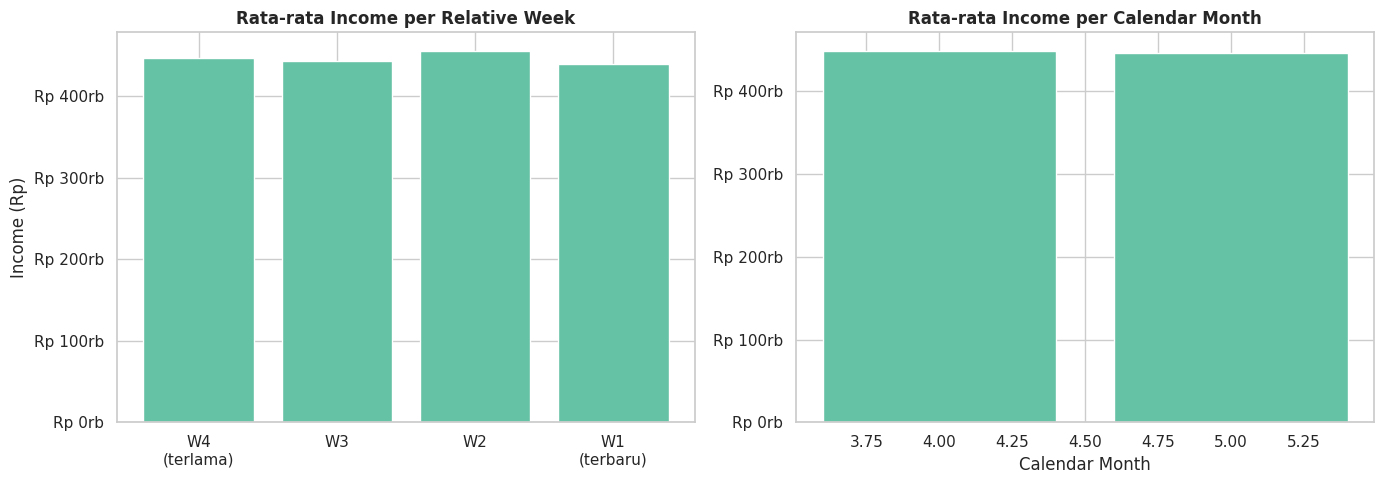

✓ Chart disimpan: outputs/charts/temporal_mapping_overview.png


In [9]:
# CELL 02.9 — Chart: Income per relative_week dan calendar_month
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rw_mean = df_survey_weekly_long.groupby("relative_week")["weekly_income"].mean()
labels = ["W4\n(terlama)", "W3", "W2", "W1\n(terbaru)"]
axes[0].bar(labels, [rw_mean.get(-4,0), rw_mean.get(-3,0), rw_mean.get(-2,0), rw_mean.get(-1,0)])
axes[0].set_title("Rata-rata Income per Relative Week", fontweight="bold")
axes[0].set_ylabel("Income (Rp)")
axes[0].yaxis.set_major_formatter(IDR_FMT)

cm_mean = df_survey_weekly_long.dropna(subset=["calendar_month"]).groupby("calendar_month")["weekly_income"].mean()
axes[1].bar(cm_mean.index.astype(int), cm_mean.values)
axes[1].set_title("Rata-rata Income per Calendar Month", fontweight="bold")
axes[1].set_xlabel("Calendar Month")
axes[1].yaxis.set_major_formatter(IDR_FMT)

plt.tight_layout()
ensure_dir("outputs/charts/temporal_mapping_overview.png")
plt.savefig("outputs/charts/temporal_mapping_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart disimpan: outputs/charts/temporal_mapping_overview.png")

In [10]:
# GIT PUSH — Commit dan push output notebook ini ke GitHub
import os, subprocess

LOCAL_DIR   = "/content/fingo-income-analysis"
BRANCH_NAME = "feat/income-predictor-final"
NOTEBOOK_NAME = "02_Temporal_Mapping.ipynb"

os.chdir(LOCAL_DIR)

def run_cmd(cmd, check=True):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(f"$ {cmd}")
    if r.stdout.strip(): print(r.stdout.strip())
    if r.stderr.strip(): print(r.stderr.strip())
    if check and r.returncode != 0:
        raise RuntimeError(f"Command gagal: {cmd}")
    return r

run_cmd('git config user.email "adelineclarisya@gmail.com"')
run_cmd('git config user.name "ClarisyaA"')

print("\n[1] Cek status")
run_cmd("git status --short", check=False)

print("\n[2] Add semua perubahan output")
run_cmd("git add data/ outputs/ notebooks/ *.ipynb", check=False)

print("\n[3] Commit")
commit_result = run_cmd(
    f'git commit -m "feat(DS2): output dari {NOTEBOOK_NAME}"',
    check=False
)
if commit_result.returncode != 0:
    print("[INFO] Tidak ada perubahan baru, skip commit.")

print("\n[4] Fetch remote terbaru")
run_cmd("git fetch origin")

print("\n[5] Rebase lalu push")
run_cmd(f"git pull --rebase origin {BRANCH_NAME}", check=False)
run_cmd(f"git push -u origin {BRANCH_NAME}")

print("\n✓ Push berhasil!")

$ git config user.email "adelineclarisya@gmail.com"
$ git config user.name "ClarisyaA"

[1] Cek status
$ git status --short
?? data/processed/survey_temporal_mapped.csv
?? data/processed/survey_weekly_income_long.csv
?? outputs/charts/temporal_mapping_overview.png

[2] Add semua perubahan output
$ git add data/ outputs/ notebooks/ *.ipynb

[3] Commit
$ git commit -m "feat(DS2): output dari 02_Temporal_Mapping.ipynb"
[feat/income-predictor-final 250635a] feat(DS2): output dari 02_Temporal_Mapping.ipynb
 3 files changed, 1922 insertions(+)
 create mode 100644 data/processed/survey_temporal_mapped.csv
 create mode 100644 data/processed/survey_weekly_income_long.csv
 create mode 100644 outputs/charts/temporal_mapping_overview.png

[4] Fetch remote terbaru
$ git fetch origin

[5] Rebase lalu push
$ git pull --rebase origin feat/income-predictor-final
Current branch feat/income-predictor-final is up to date.
From https://github.com/ClarisyaA/fingo-income-analysis
 * branch            feat/in